In [1]:
import pandas as pd, numpy as np
from sklearn.datasets import load_iris
iris = load_iris()

In [2]:
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = iris.target
df.sample(5)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
39,5.1,3.4,1.5,0.2,0
109,7.2,3.6,6.1,2.5,2
105,7.6,3.0,6.6,2.1,2
38,4.4,3.0,1.3,0.2,0
57,4.9,2.4,3.3,1.0,1


In [3]:
X=df.iloc[:,:-1].values
y=df['species'].values

In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=51)

In [5]:
from sklearn.linear_model import Perceptron

In [6]:
y_p1 = (y_train != 0).astype(int)

In [7]:
slp1 = Perceptron(max_iter=100, eta0=0.01, random_state=15)
slp1.fit(X_train, y_p1)

,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,100
,tol,0.001
,shuffle,True
,verbose,0
,eta0,0.01
,n_jobs,None
,random_state,15


In [8]:
mask = y_train!=0
X_p2 = X_train[mask]
y_p2 = y_train[mask]
y_p2 = (y_p2 == 2).astype(int)

In [9]:
slp2 = Perceptron(max_iter=100, eta0=0.01, random_state=15)
slp2.fit(X_p2, y_p2)

,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,100
,tol,0.001
,shuffle,True
,verbose,0
,eta0,0.01
,n_jobs,None
,random_state,15


In [10]:
def predict_two_layer(X):
    y_pred = []

    for x in X:
        p1 = slp1.predict(x.reshape(1, -1))[0]

        if p1 == 0:
            y_pred.append(0)  # setosa
        else:
            p2 = slp2.predict(x.reshape(1, -1))[0]
            y_pred.append(2 if p2 == 1 else 1)

    return np.array(y_pred)

In [11]:
y_pred = predict_two_layer(X_test)
y_pred

array([1, 2, 1, 0, 1, 2, 2, 2, 0, 2, 2, 0, 1, 2, 2, 2, 2, 2, 2, 0, 2, 2,
       0, 0, 1, 2, 0, 0, 0, 2, 1, 1, 0, 1, 1, 2, 2, 1])

In [12]:
y_test

array([1, 2, 1, 0, 1, 2, 2, 2, 0, 2, 2, 0, 1, 2, 2, 1, 2, 2, 2, 0, 2, 2,
       0, 0, 1, 2, 0, 0, 0, 2, 1, 1, 0, 1, 1, 1, 1, 1])

In [13]:
import nbimporter
from PerformanceMetrics import PerformanceMetrics

In [14]:
metrics = PerformanceMetrics(y_test, y_pred)

In [15]:
metrics.report()

{'Accuracy': '0.921',
 'Precision': '0.944',
 'Recall': '0.923',
 'F1 Score': '0.934'}

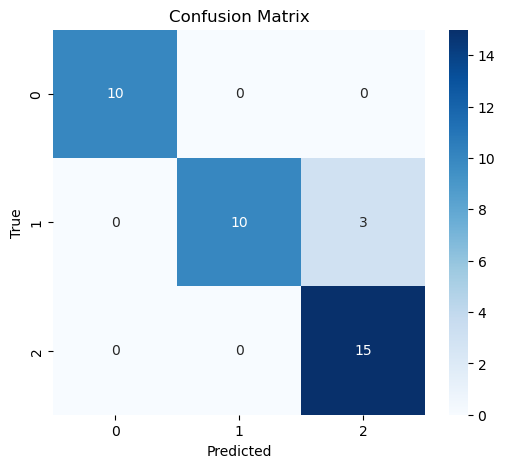

In [16]:
metrics.plot_confusion_matrix()